# Reinforcement learning from verifiable rewards, in five acts

**CERN STEAM Academy 2026 - Advanced Machine Learning**

In notebook 1 the function approximator was a small MLP and the reward came from a
physics simulator. Here the function approximator is a language model with half a billion
parameters and the reward is a Python function you are about to write. Everything else -
bootstrapping off your own estimates, learning off-policy from your own samples,
optimising a proxy for what you actually want - is the same, and so are the ways it goes
wrong.

We will train Qwen2.5-0.5B-Instruct to multiply integers using **GRPO** (Group Relative
Policy Optimisation), the algorithm behind DeepSeek-R1-Zero. It will work. The model will
get measurably better at the task we reward.

Then we will look at what it cost.

## The five acts

| Act | What happens | Time |
|---|---|---|
| 0 | Meet the model. Measure what it can do *before* we touch it. | 12 min |
| 1 | Train it, hard, with the KL leash off. | 22 min |
| 2 | The reveal: the same measurements, after. | 10 min |
| 3 | Diagnose. No training - just reading the logs carefully. | 12 min |
| 4 | The fix: change one line and run it again. | 20 min |
| 5 | Discussion. | 9 min |

## The one idea

GRPO is policy-gradient RL with the value network deleted. Instead of learning a critic to
estimate "how good is this state", it samples $G$ completions for the same prompt and
uses the group itself as the baseline:

$$A_i = \frac{r_i - \mathrm{mean}(r_1 \ldots r_G)}{\mathrm{std}(r_1 \ldots r_G) + \epsilon}$$

A completion that beat its siblings gets a positive advantage and is made more likely; one
that lost gets a negative advantage and is made less likely. That is the whole algorithm.

Hold on to one consequence, because Act 3 is built on it: **if all $G$ completions score
the same, the numerator is zero, the advantage is exactly zero, and that prompt teaches
the model nothing at all.**

In [1]:
"""Setup. Run this first, and read the two flags: they control everything below."""
import json
import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import torch

from rlpractice import arithmetic, dashboard, evaluation, grpo, rewards
from rlpractice.callbacks import (
    InstrumentedGRPOTrainer,
    MetricsCSVCallback,
    NaNGuardCallback,
    TimeBudgetCallback,
    peak_memory_report,
)

# ---------------------------------------------------------------------------------
# FLAG 1: the insurance policy.
#
# True  - train for real. This is what you want.
# False - load the reference adapters and logs that were pre-staged with
#         tools/prestage.py. Every plot, every evaluation and every exercise below
#         still works; you skip only the waiting. Flip this if your GPU misbehaves,
#         if a run diverges, or if the room runs out of time.
# ---------------------------------------------------------------------------------
TRAIN_FROM_SCRATCH = True

# ---------------------------------------------------------------------------------
# FLAG 2: the instructor escape hatch. Leave it alone.
#
# Set the environment variable RLPRACTICE_REFERENCE=1 to fill the exercise holes with
# the reference implementations. This exists so the notebook can be executed
# unattended in CI; using it while you are meant to be doing the exercise only cheats
# you.
# ---------------------------------------------------------------------------------
USE_REFERENCE_SOLUTIONS = os.environ.get("RLPRACTICE_REFERENCE", "0") == "1"

ASSETS = os.path.abspath("../assets")
LOGS = os.path.join(ASSETS, "reference_logs")
RUNS = os.path.abspath("runs")
# This notebook's own measurements go under runs/, not into assets/. assets/ holds the
# pre-staged reference artefacts, and those must keep matching the reference adapters
# they were measured from - otherwise the TRAIN_FROM_SCRATCH = False path would be
# reading one run's snapshots against another run's weights.
SNAPSHOTS = os.path.join(RUNS, "snapshots")
os.makedirs(SNAPSHOTS, exist_ok=True)

print(f"torch {torch.__version__}")
print(f"CUDA available    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device            {torch.cuda.get_device_name(0)}")
    print(f"capability        {torch.cuda.get_device_capability()}")
    print(f"total memory      {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"\nTRAIN_FROM_SCRATCH      {TRAIN_FROM_SCRATCH}")
print(f"USE_REFERENCE_SOLUTIONS {USE_REFERENCE_SOLUTIONS}")

/mnt/mbunino/rlpractice/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.3.1+cu121
CUDA available    True
device            Tesla T4
capability        (7, 5)
total memory      15.6 GB

TRAIN_FROM_SCRATCH      True
USE_REFERENCE_SOLUTIONS False


---

# Act 0 - Meet the model

Twelve minutes, no training. This act exists because of a discipline that is easy to skip
and expensive to skip: **measure the thing you are about to change, before you change
it, with the code you will use to measure it afterwards.**

Every number in Act 2 and Act 4 is a comparison against a number taken here. If the
measurement drifts between acts - a different decoding temperature, a different number of
eval problems, a different corpus - then the comparison measures the change in the
evaluator rather than the change in the model, and it does so silently. That is why the
functions in `rlpractice/evaluation.py` take no configuration arguments. They are frozen.

In [2]:
"""Load the base model. Three decisions are worth stating out loud."""
model, tokenizer = grpo.load_model_and_tokenizer()

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


loaded Qwen/Qwen2.5-0.5B-Instruct
  parameters      494.0 M
  dtype           torch.float32
  weight memory   1.84 GB
  attention       sdpa
  vocabulary      151,936 tokens
  loaded from     the hub


Those three decisions:

**fp32 weights, and `fp16=True` in the training config.** Not fp16 weights. Setting
`fp16=True` turns on autocast plus a `GradScaler`: the master copy of the weights stays in
fp32, the arithmetic happens in fp16, and the scaler keeps gradients inside fp16's
representable range. Loading fp16 weights *and* enabling fp16 gives you fp16 master
weights with no scaler headroom, which is the classic recipe for a loss that becomes NaN
twenty steps in. At 0.5B parameters, fp32 costs about 2 GB, which is nothing here.

**SDPA attention, not flash-attention.** The T4 is Turing, compute capability (7, 5), and
flash-attention has no kernels for it. PyTorch's own fused attention works everywhere.

**No bf16, anywhere.** Turing has no bf16 tensor cores. Note that
`torch.cuda.is_bf16_supported()` returns `True` on a T4 regardless, because it falls back
to checking whether a `bfloat16` tensor can be *allocated* - which it can, and then runs
slowly and oddly. Trust the compute capability, not the flag.

## The memory arithmetic, which is not about the model

The instinct is that a 0.5B model is small, so batch size is free. It is not, and the
reason is the vocabulary.

In [3]:
"""Why the batch geometry below looks the way it does. Do the arithmetic, do not guess."""
vocab = model.config.vocab_size
seq_len = 250          # prompt plus completion, roughly
bytes_fp32 = 4

print(f"vocabulary size                {vocab:,} tokens")
print()
print("Logits tensor during the log-probability forward pass: batch x seq_len x vocab")
print()
for batch in (8, 16, 32, 64):
    gb = batch * seq_len * vocab * bytes_fp32 / 1024**3
    verdict = "fits" if gb < 10 else "OOM on a 16 GB card"
    print(f"  batch {batch:3d}:  {gb:6.2f} GB of logits alone   ({verdict})")

print()
print("This is why generation batch and forward batch are different things.")
print("We generate 8 completions per prompt because GRPO needs a group to normalise")
print("within, but we only ever push 8 sequences through the forward pass at a time,")
print("and reach an effective batch of 2 prompts by accumulating gradients instead.")

vocabulary size                151,936 tokens

Logits tensor during the log-probability forward pass: batch x seq_len x vocab

  batch   8:    1.13 GB of logits alone   (fits)
  batch  16:    2.26 GB of logits alone   (fits)
  batch  32:    4.53 GB of logits alone   (fits)
  batch  64:    9.06 GB of logits alone   (fits)

This is why generation batch and forward batch are different things.
We generate 8 completions per prompt because GRPO needs a group to normalise
within, but we only ever push 8 sequences through the forward pass at a time,
and reach an effective batch of 2 prompts by accumulating gradients instead.


## The task

Multiply two integers. Reason inside `<think></think>`, give the final number inside
`<answer></answer>`. This is the DeepSeek-R1-Zero template, and the reason it is a good
teaching task is that the reward is **verifiable**: there is exactly one right answer and
checking it is a comparison, not a judgement. No reward model, no preference data, no
annotator. The entire training signal will be two Python functions.

The data is generated from a seed rather than downloaded. That is not laziness:

1. nothing can fail at the worst possible moment because a download was blocked;
2. difficulty becomes a dial we can turn, which the sweep below depends on;
3. the held-out split can be made *provably* disjoint from the training split rather than
   probably disjoint.

In [4]:
"""Build the splits and look at an actual prompt. Silent tensors teach nothing."""
train_dataset, eval_dataset = grpo.build_splits()

print(f"training difficulty: {grpo.TRAIN_MIX}")
print()
print(arithmetic.describe(train_dataset, "train"))
print(arithmetic.describe(eval_dataset, "eval "))

from collections import Counter
def digit_shape(dataset):
    return dict(Counter((len(str(a)), len(str(b))) for a, b in arithmetic.dataset_pairs(dataset)))
print(f"\ntrain composition {digit_shape(train_dataset)}")
print(f"eval  composition {digit_shape(eval_dataset)}")

train_pairs = set(arithmetic.dataset_pairs(train_dataset))
eval_pairs = set(arithmetic.dataset_pairs(eval_dataset))
print(f"\noverlap between train and eval: {len(train_pairs & eval_pairs)} problems")

example = eval_dataset[0]
print(f"\nrow 0 raw: a={example['a']}, b={example['b']}, answer={example['answer']!r}")
print("\nrow 0 prompt, as chat messages:")
for message in example["prompt"]:
    print(f"  [{message['role']}] {message['content']}")

rendered = tokenizer.apply_chat_template(
    example["prompt"], tokenize=False, add_generation_prompt=True
)
n_tokens = len(tokenizer(rendered, add_special_tokens=False).input_ids)
print(f"\nrendered through the chat template ({n_tokens} tokens, "
      f"budget is {grpo.GRPO_COMMON['max_prompt_length']}):")
print(repr(rendered))

training difficulty: ((2, 1),)

train: 512 problems, a in [10, 99], b in [2, 9], columns=['prompt', 'answer', 'a', 'b']
eval : 64 problems, a in [10, 99], b in [2, 9], columns=['prompt', 'answer', 'a', 'b']

train composition {(2, 1): 512}
eval  composition {(2, 1): 64}

overlap between train and eval: 0 problems

row 0 raw: a=25, b=3, answer='75'

row 0 prompt, as chat messages:
  [system] You are a careful calculator. Think step by step inside <think> </think> tags, then give the final number inside <answer> </answer> tags. Example: <think> your reasoning </think><answer> 42 </answer>
  [user] What is 25 times 3?

rendered through the chat template (73 tokens, budget is 160):
'<|im_start|>system\nYou are a careful calculator. Think step by step inside <think> </think> tags, then give the final number inside <answer> </answer> tags. Example: <think> your reasoning </think><answer> 42 </answer><|im_end|>\n<|im_start|>user\nWhat is 25 times 3?<|im_end|>\n<|im_start|>assistant\n'


## What does it do right now?

Before any training, look at the raw behaviour. Not a metric - the actual text. Three
arithmetic prompts and five general prompts, greedy decoding.

Watch two things. First, whether it obeys the output contract at all. Second, and more
importantly, what its *general* prose looks like, because those five general prompts are
the control group for this entire notebook. Nothing we are about to optimise mentions
them.

In [5]:
"""Base behaviour on the task, and on prose. Read the text, not just the numbers."""
task_chats = list(eval_dataset.select(range(3))["prompt"])
task_outputs = evaluation.generate_greedy(model, tokenizer, task_chats)

print("=" * 78)
print("ARITHMETIC (greedy)")
print("=" * 78)
for row, output in zip(eval_dataset.select(range(3)), task_outputs):
    print(f"\n  {row['a']} x {row['b']} = {row['answer']}")
    print(f"  model: {output.strip()!r}")

print()
print("=" * 78)
print("GENERAL PROSE (greedy) - the control group")
print("=" * 78)
base_generations = evaluation.sample_general_generations(model, tokenizer)
for prompt, output in zip(evaluation.GENERAL_PROMPTS, base_generations):
    print(f"\n  {prompt}")
    print(f"  ----> {output.strip()[:300]}")

ARITHMETIC (greedy)

  25 x 3 = 75
  model: '<think> multiplication </think> gives us the answer: <answer> 75 </answer>'

  28 x 9 = 252
  model: '<think> calculation steps </think> :\n1. Multiply 28 by 9.\n2. 28 * 9 = 252\n\n<answer> 252 </answer>'

  33 x 3 = 99
  model: '<think> multiplication </think>'

GENERAL PROSE (greedy) - the control group



  Write a short paragraph explaining why sea cliffs retreat over time.
  ----> Sea cliffs, the rugged and often dramatic formations that form on the coastlines of many coastal areas around the world, undergo significant changes over time due to various geological processes. These changes can be attributed to several factors:

1. **Natural Weathering**: The weathering process i

  Give three pieces of practical advice to someone starting a vegetable garden.
  ----> Sure! Starting a vegetable garden can be both rewarding and challenging. Here are three practical tips that might help you get started:

1. **Choose the Right Location**: The ideal location for a vegetable garden is in a spot that receives at least 6-8 hours of direct sunlight per day. This helps in

  Explain the difference between a simile and a metaphor, with one example of each.
  ----> A simile is an expression that compares two different things using "like" or "as." It uses words like "like," "as if," "as though," or "

## The difficulty sweep

Now the design decision the rest of the notebook rests on: **what should we train on?**

The naive answer is "the hardest thing it can nearly do". The correct answer comes from
the advantage formula. GRPO normalises rewards *within a group of $G$ completions for the
same prompt*:

$$A_i = \frac{r_i - \mathrm{mean}(r_1 \ldots r_G)}{\mathrm{std}(r_1 \ldots r_G) + \epsilon}$$

If the model gets a problem right 5% of the time, then almost every group of eight is
eight failures: identical rewards, zero standard deviation, zero numerator, **zero
advantage for every completion**. If it gets it right 95% of the time, almost every group
is eight successes, and the same thing happens. In both cases the prompt contributes no
gradient at all, and - this is the part that catches people - nothing in the training logs
looks broken. The loss is fine. The run takes just as long. The model simply does not
move.

So we sweep the difficulty and measure two things:

* **greedy pass@1**, the number everyone quotes;
* **the sampled pass rate at temperature 1.0**, which is the distribution GRPO will
  actually draw from, together with the fraction of groups that come out with zero
  variance.

The second one is the one that matters, and the two do not agree.

In [6]:
"""Sweep the difficulty. Greedy and sampled, because they disagree and only one counts."""
sweep = {}
for digits_a, digits_b in arithmetic.sweep_settings():
    probe = arithmetic.make_dataset(
        n=32, digits_a=digits_a, digits_b=digits_b, seed=evaluation.EVAL_SEED
    )
    greedy = evaluation.eval_task_accuracy(model, tokenizer, probe, n=32)
    sampled = evaluation.eval_sampled_pass_rate(model, tokenizer, probe, n=12)
    sweep[(digits_a, digits_b)] = {"greedy": greedy, **sampled}
    print(
        f"  ({digits_a},{digits_b}): greedy pass@1 {greedy:.3f} | "
        f"sampled pass rate {sampled['sampled_pass_rate']:.3f} | "
        f"zero-variance groups {sampled['zero_variance_groups']:.2f}"
    )

labels = [f"{a}x{b}" for a, b in sweep]
fig, (ax_rate, ax_zero) = plt.subplots(1, 2, figsize=(11, 4))

x = range(len(labels))
ax_rate.bar([i - 0.2 for i in x], [s["greedy"] for s in sweep.values()], width=0.4,
            label="greedy pass@1", color="C0")
ax_rate.bar([i + 0.2 for i in x], [s["sampled_pass_rate"] for s in sweep.values()], width=0.4,
            label="sampled pass rate (T=1.0)", color="C1")
ax_rate.axhspan(0.20, 0.50, color="green", alpha=0.12)
ax_rate.text(-0.45, 0.51, "the 20-50% band", fontsize=8, color="green")
ax_rate.set_xticks(list(x)); ax_rate.set_xticklabels(labels)
ax_rate.set_ylabel("pass rate"); ax_rate.set_ylim(0, 1)
ax_rate.set_title("Base-model difficulty sweep", fontsize=10)
ax_rate.legend(fontsize=8); ax_rate.grid(alpha=0.3, axis="y")

ax_zero.bar(labels, [s["zero_variance_groups"] for s in sweep.values()], color="C3")
ax_zero.set_ylabel("fraction of groups with zero reward variance")
ax_zero.set_ylim(0, 1)
ax_zero.set_title("Fraction of the batch that would teach nothing", fontsize=10)
ax_zero.grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

  (1,1): greedy pass@1 0.531 | sampled pass rate 0.344 | zero-variance groups 0.00


  (2,1): greedy pass@1 0.594 | sampled pass rate 0.271 | zero-variance groups 0.17


  (2,2): greedy pass@1 0.562 | sampled pass rate 0.135 | zero-variance groups 0.00


  (3,2): greedy pass@1 0.281 | sampled pass rate 0.094 | zero-variance groups 0.08


<Figure size 1100x400 with 2 Axes>

### Exercise 0

Look at the sweep and answer, in the cell below:

1. Which settings have a **sampled** pass rate inside the 20-50% band?
2. Among those, which would you actually train on, and why? (Look at how many distinct
   problems each setting *has*. One of them has very few.)
3. Why would a task the model passes 5% of the time and a task it passes 95% of the time
   both teach GRPO nothing? Answer in terms of the advantage formula, not in terms of
   "too hard" and "too easy".

<!-- TODO(hint): which settings sit in the 20-50% band, which would you train on, and why do 5% and 95% both produce zero gradient? -->
<!-- BEGIN SOLUTION -->
**1.** Measured on the base model, the sampled pass rates at temperature 1.0 land around
0.27 for one-by-one digits, 0.28 for two-by-one, 0.18 for two-by-two and 0.13 for
three-by-two. The first two are comfortably inside the band and the others sit at or below
its lower edge. Note that greedy pass@1 tells a different and misleading story - it is
around 0.53-0.59 for the three easier settings, which would have pushed us towards the
hardest one.

**2.** Two-digit by one-digit, as the *starting* point. One-by-one digits is also in the
band, but the entire problem space is only $8 \times 8 = 64$ distinct problems once the
trivial multiplications by zero and one are excluded. A held-out split would consume most
of the space and the training set would be nearly the whole distribution, so "held-out
accuracy" would stop meaning anything. Two-by-one has $90 \times 8 = 720$ problems, which
is enough to hold out 64 and still train on genuinely unseen ones.

But see the cell below: training on two-by-one *alone* turns out not to survive contact
with the experiment, and the reason is the same zero-advantage argument in part 3.

**3.** Because the advantage is a *within-group* z-score, not an absolute reward. At a 5%
pass rate almost every group of eight completions is eight failures; every $r_i$ equals
the group mean, so $r_i - \mathrm{mean} = 0$ and $A_i = 0$ for all $i$. At 95% almost every
group is eight successes and exactly the same thing happens. The gradient of the GRPO
objective is proportional to the advantage, so both extremes produce no update. What GRPO
needs is not difficulty but *disagreement within the group*: some completions better than
their siblings, so that there is something to push up and something to push down. That is
why the right-hand panel above - the fraction of zero-variance groups - is the diagnostic
that actually predicts whether training will do anything.
<!-- END SOLUTION -->

### What happens next, and why Act 3 is about it

Two-by-one digits it is. But the choice has a consequence that only shows up once training
starts, and it is worth knowing in advance because you are about to watch it happen.

GRPO learns this task quickly - held-out accuracy goes from about 0.62 to about 0.94
within forty steps. And then three things happen in lockstep:

1. reward saturates at its maximum, because there is nothing left to get right;
2. policy entropy collapses towards **0.000** - the policy becomes deterministic;
3. and therefore all eight completions in a group become *identical*. Their rewards are
   identical, so the advantage is exactly zero, so the gradient is exactly zero.

Measured on this configuration, `frac_zero_std_groups` reaches **1.00** and stays there.
The run continues, the dashboard keeps updating, the loss sits where it always sat - and
nothing is being learned. This is the same zero-advantage argument from the exercise above,
arriving from the other direction: we chose a difficulty that was not too easy *for the
base model*, but training made it too easy, and the objective has no way to notice.

We tried the obvious repair - mixing in harder two-by-two problems, which the model does
not saturate. It works, in the sense that entropy survives (0.02 to 0.49 rather than 0.000)
and general perplexity moves considerably further. It also made held-out accuracy go
*down*, because the harder half degrades faster than the easier half improves, and it was
not reproducible: two runs of the identical configuration gave x1.20 and x1.03 perplexity
at the same step count. So the session trains on the single setting, and the mixture stays
here as a note.

Keep the three-step chain above in mind. Act 3 asks you to find it in the logs.

In [7]:
"""The BEFORE snapshot. Everything in Acts 2 and 4 is compared against this."""
before = evaluation.snapshot(
    model, tokenizer, eval_dataset, tag="before", out_dir=SNAPSHOTS, n_task=grpo.N_EVAL
)
evaluation.print_snapshot(before, show_generations=False)
print(f"\nsaved to {before['path']}")
print("\nThe three frozen measurements, and what each is for:")
print("  task_accuracy      - did it learn the thing we rewarded?")
print("  general_perplexity - what did that cost? (cheap: one forward pass, no generation)")
print("  general_generations - what did that cost, in a form a human can read?")

=== snapshot: before ===
  task accuracy (n=64, greedy) : 0.625
  general-text perplexity                      : 27.595

saved to /home/mbunino2/code/26-ADVANCED-ML/rl-practice/notebooks/runs/snapshots/before.json

The three frozen measurements, and what each is for:
  task_accuracy      - did it learn the thing we rewarded?
  general_perplexity - what did that cost? (cheap: one forward pass, no generation)
  general_generations - what did that cost, in a form a human can read?


---

# Act 1 - Train it, hard

Twenty-two minutes. We are going to run GRPO with the KL penalty set to **zero**.

The full GRPO objective has a leash in it - a KL divergence term that penalises drifting
away from the model you started from:

$$\mathcal{L} = -\mathbb{E}\left[ \frac{\pi_\theta(o)}{\pi_{\theta_{old}}(o)} A \right]
  + \beta \, \mathbb{D}_{KL}\!\left[\pi_\theta \,\|\, \pi_{ref}\right]$$

Setting $\beta = 0$ removes the second term entirely. Nothing then constrains how far the
policy travels from the reference model; the only pressure on it is the reward.

This is a deliberately hot configuration. We want the failure to be legible in fifteen
minutes rather than subtle over fifteen hours.

## First, the objective - which is yours to write

There is no reward model here. The entire training signal is two Python functions. Write
them.

In [8]:
def format_reward(completions, **kwargs) -> list[float]:
    """Reward the <think>...</think><answer>...</answer> output contract.

    TRL calls this as fn(prompts=..., completions=..., **dataset_columns) and expects a
    list of floats, one per completion, in the same order.

    Because the dataset is conversational, `completions` arrives as a list of message
    lists, not a list of strings. rewards.completion_texts() normalises that for you.

    Scoring, per completion:
      rewards.FORMAT_FULL    (1.0) if the whole completion is a think block followed by an
                                   answer block, ignoring surrounding whitespace.
                                   arithmetic.FORMAT_RE matches exactly this.
      rewards.FORMAT_PARTIAL (0.5) if there is an <answer>...</answer> block somewhere but
                                   the strict contract is not met.
      0.0                          otherwise.

    Partial credit matters more than it looks: it puts a gradient between "nearly the
    right shape" and "no shape at all", which is most of what the model has to learn in
    the first few steps.
    """
    # TODO(hint): normalise with rewards.completion_texts, then score each string against
    # arithmetic.FORMAT_RE for full credit, falling back to
    # arithmetic.extract_answer_text for partial credit
    # BEGIN SOLUTION
    scores = []
    for text in rewards.completion_texts(completions):
        if arithmetic.FORMAT_RE.match(text) is not None:
            scores.append(rewards.FORMAT_FULL)
        elif arithmetic.extract_answer_text(text) is not None:
            scores.append(rewards.FORMAT_PARTIAL)
        else:
            scores.append(0.0)
    return scores
    # END SOLUTION


def correctness_reward(completions, answer, **kwargs) -> list[float]:
    """Reward an exactly correct product.

    `answer` is the ground-truth column of the dataset, which TRL forwards as a list of
    strings, one per completion, aligned with `completions`.

    Score rewards.CORRECT_FULL (2.0) for an exact integer match and 0.0 for anything
    else, including a completion with no answer block at all.

    Use arithmetic.extract_answer_int, which is deliberately lenient: it takes the last
    <answer> block and tolerates thousands separators. Do NOT re-check the format here -
    the point of having two reward functions is that they measure two different things
    rather than one thing twice.
    """
    # TODO(hint): normalise with rewards.completion_texts, extract each predicted integer
    # with arithmetic.extract_answer_int, and compare against int(expected)
    # BEGIN SOLUTION
    scores = []
    for text, expected in zip(rewards.completion_texts(completions), answer):
        predicted = arithmetic.extract_answer_int(text)
        scores.append(
            rewards.CORRECT_FULL if predicted is not None and predicted == int(expected) else 0.0
        )
    return scores
    # END SOLUTION

In [9]:
if USE_REFERENCE_SOLUTIONS:
    from rlpractice.rewards import correctness_reward, format_reward  # noqa: F811
    print("using the reference reward implementations (RLPRACTICE_REFERENCE=1)")

In [10]:
"""Test cell. A reward function that silently returns the wrong shape is a miserable
thing to debug against a live training loop, so debug it here instead."""
rewards.self_check(format_reward, correctness_reward)

print("\nScoring the base model's actual completions from Act 0:")
example_rows = list(eval_dataset.select(range(3)))
conversational = rewards.as_conversational([o for o in task_outputs])
f_scores = format_reward(completions=conversational)
c_scores = correctness_reward(completions=conversational, answer=[r["answer"] for r in example_rows])
for row, output, f, c in zip(example_rows, task_outputs, f_scores, c_scores):
    print(f"\n  {row['a']} x {row['b']} = {row['answer']}   format {f:.1f} + correct {c:.1f} = {f + c:.1f}")
    print(f"    {output.strip()[:120]!r}")

reward self-check passed: 13 cases x 2 calling conventions

Scoring the base model's actual completions from Act 0:

  25 x 3 = 75   format 0.5 + correct 2.0 = 2.5
    '<think> multiplication </think> gives us the answer: <answer> 75 </answer>'

  28 x 9 = 252   format 0.5 + correct 2.0 = 2.5
    '<think> calculation steps </think> :\n1. Multiply 28 by 9.\n2. 28 * 9 = 252\n\n<answer> 252 </answer>'

  33 x 3 = 99   format 0.0 + correct 0.0 = 0.0
    '<think> multiplication </think>'


## The configuration

Every number here is a decision. The four at the top are the memory budget worked out in
Act 0; the rest are the experiment.

In [11]:
"""Build the Act 1 configuration and print it. Nothing about this run should be implicit."""
ACT1_CSV = os.path.join(RUNS, "act1.csv")

act1_config = grpo.build_grpo_config(
    beta=0.0,                                     # <-- the leash, off
    max_steps=grpo.MAX_STEPS_CAP,
    output_dir=os.path.join(RUNS, "act1_trainer"),
)

print("Act 1 configuration")
print(grpo.describe_config(act1_config))
print("\nLoRA:")
for key, value in grpo.LORA_KWARGS.items():
    print(f"  {key:<16} {value}")
print("\ntarget_modules='all-linear' rather than the attention projections alone: a lot of")
print("a small model's factual and stylistic behaviour lives in the MLP matrices, and we")
print("want whatever happens in Act 2 to be visible rather than subtle.")

Act 1 configuration
  beta                         0.0
  learning_rate                0.0002
  temperature                  1.0
  num_generations              8
  per_device_train_batch_size  8
  gradient_accumulation_steps  2
  max_prompt_length            160
  max_completion_length        128
  max_steps                    150
  fp16                         True
  bf16                         False
  use_vllm                     False
  lr_scheduler_type            SchedulerType.CONSTANT_WITH_WARMUP
  warmup_steps                 3
  seed                         0
  prompts / optimiser step     2
  completions / optimiser step  16

LoRA:
  r                16
  lora_alpha       32
  lora_dropout     0.0
  target_modules   all-linear
  task_type        CAUSAL_LM

target_modules='all-linear' rather than the attention projections alone: a lot of
a small model's factual and stylistic behaviour lives in the MLP matrices, and we
want whatever happens in Act 2 to be visible rather than sub

## The step budget, measured rather than guessed

A hard-coded `max_steps` is a promise about hardware you do not control. Instead the run
measures the cost of its own first few steps and converts a **wall-clock** budget into a
step budget:

```
max_steps = min(MAX_STEPS_CAP, TIME_BUDGET_SECONDS / measured_seconds_per_step)
```

with one subtlety that cost us a run when we got it wrong: **the first step must not be
measured.** It carries CUDA context creation, kernel autotuning and the dataloader
spinning up. Measured against a steady state of about 5 s/step it came out at 17 s/step,
which projected a budget three times too small and quietly turned a fifteen-minute run
into a four-minute one. `TimeBudgetCallback` discards the warm-up step, then measures.

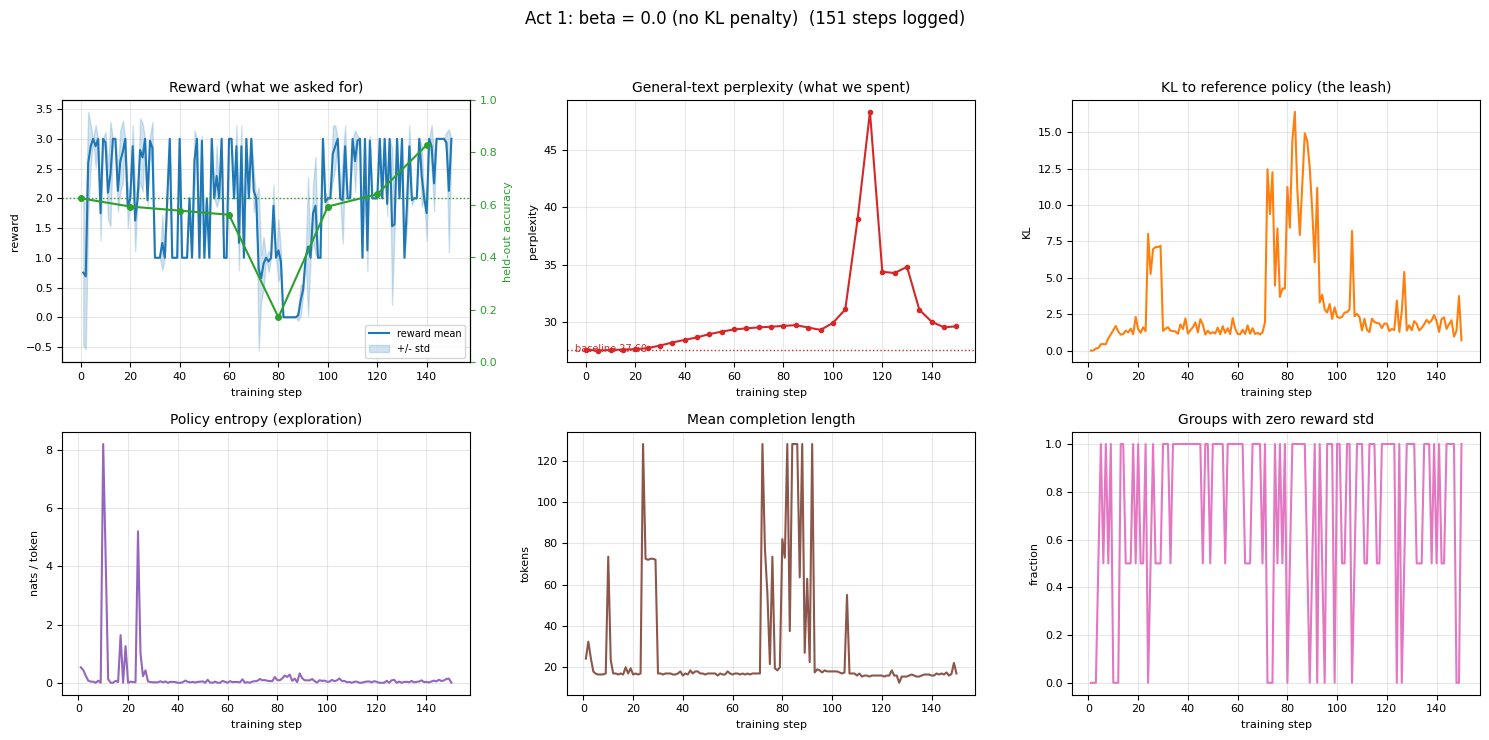

[metrics] 151 rows -> /home/mbunino2/code/26-ADVANCED-ML/rl-practice/notebooks/runs/act1.csv; 892 s total, 72 s of that in evaluation



Act 1 finished: 150 steps in 14.9 min
peak memory: 7.04 GB allocated (the acceptance budget is 14 GB)


In [12]:
"""Act 1. This is the long cell: about 15 minutes of training plus periodic evaluation.

The dashboard redraws every 10 steps. Watch the reward climb - and watch the KL panel,
which is measured even though beta = 0 means it is not penalised."""
if TRAIN_FROM_SCRATCH:
    torch.cuda.reset_peak_memory_stats()

    act1_budget = TimeBudgetCallback(grpo.ACT1_TIME_BUDGET_SECONDS, grpo.MAX_STEPS_CAP)
    act1_metrics = MetricsCSVCallback(
        csv_path=ACT1_CSV,
        tokenizer=tokenizer,
        eval_dataset=eval_dataset,
        ppl_every=grpo.PPL_EVERY,
        acc_every=grpo.ACC_EVERY,
        acc_n=grpo.ACC_N,
        dashboard_every=10,
        baseline_ppl=before["general_perplexity"],
        baseline_accuracy=before["task_accuracy"],
        title="Act 1: beta = 0.0 (no KL penalty)",
    )

    act1_trainer = InstrumentedGRPOTrainer(
        model=model,
        reward_funcs=[format_reward, correctness_reward],
        args=act1_config,
        train_dataset=train_dataset,
        peft_config=grpo.lora_config(),
        callbacks=[NaNGuardCallback(), act1_budget, act1_metrics],
    )

    act1_started = time.time()
    act1_trainer.train()
    act1_wall = time.time() - act1_started

    model_act1 = act1_trainer.model
    act1_log = ACT1_CSV
    act1_completions = act1_trainer.completion_samples
    print(f"\nAct 1 finished: {act1_trainer.state.global_step} steps in {act1_wall / 60:.1f} min")
    print(f"peak memory: {peak_memory_report()['allocated_gb']:.2f} GB allocated "
          f"(the acceptance budget is 14 GB)")
else:
    from peft import PeftModel

    act1_log = os.path.join(LOGS, "act1.csv")
    adapter = os.path.join(ASSETS, "reference_adapters", "act1")
    model_act1 = PeftModel.from_pretrained(model, adapter)
    with open(os.path.join(LOGS, "act1_completions.json")) as handle:
        act1_completions = {int(k): v for k, v in json.load(handle).items()}
    print(f"loaded the pre-staged Act 1 adapter from {adapter}")
    print(f"loaded the pre-staged Act 1 log from {act1_log}")

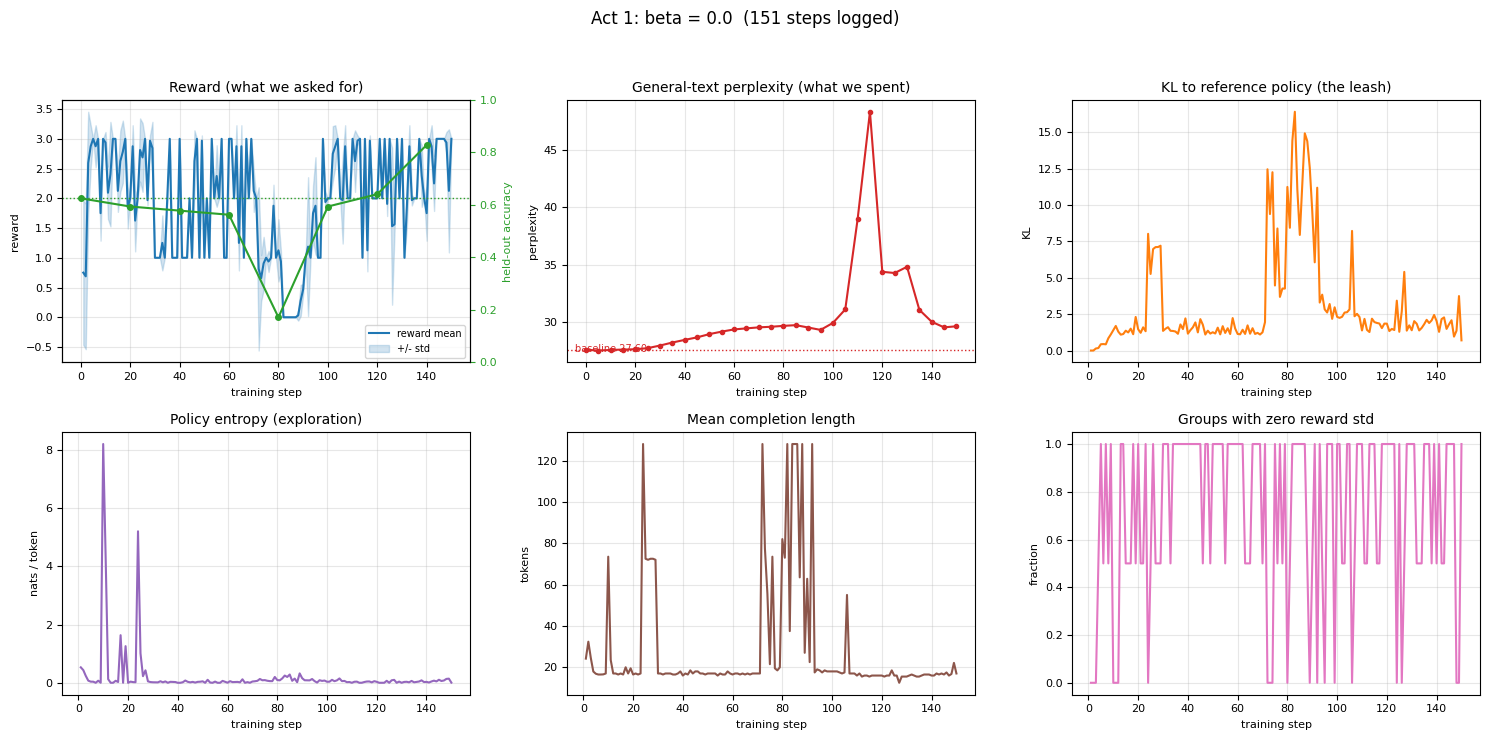

In [13]:
"""What the run actually did, as numbers rather than a moving picture."""
dashboard.plot_dashboard(
    act1_log,
    title="Act 1: beta = 0.0",
    baseline_ppl=before["general_perplexity"],
    baseline_accuracy=before["task_accuracy"],
)
plt.show()

---

# Act 2 - The reveal

Ten minutes. We now re-run **exactly** the measurements from Act 0. Same functions, same
seeds, same greedy decoding, same five prompts, same prose corpus. Nothing about the
evaluation has been touched; the only thing that changed is the model.

## Before you look: your run did one of two things

This matters, because with $\beta = 0$ **which one you get is not determined**, and that
is itself the result. Across reference runs of this exact configuration, half ended one way
and half the other:

**Outcome A - it drifted.** Reward reached its maximum within about fifteen steps and
stayed there. Held-out accuracy ended above the Act 0 baseline, around 0.80 against 0.625.
General perplexity rose steadily, by something like 8%. The model still writes English.

**Outcome B - it fell off a cliff.** The same first sixty steps: reward at maximum,
accuracy up, KL climbing quietly from 1.2 to 2.9 with nothing pushing back. Then, somewhere
around step 70, the policy left the reference distribution and did not come back. Measured
on the reference run: reward 3.0 to **0.000**, held-out accuracy to **0.000**, policy
entropy from 0.05 to **7.6 nats** - which is very nearly uniform over a 152,000-token
vocabulary, meaning the model is emitting noise - and general perplexity ended 14% up.

Notice what does *not* distinguish the two in advance. The loss is approximately zero in
both, because GRPO advantages are mean-centred by construction. The reward looks perfect in
both, right up until it does not. The only quantity that was visibly moving before the
cliff was the KL to the reference model, and nothing in the objective was reading it.

Look at your dashboard and work out which outcome you got before reading on.

In [14]:
"""The AFTER snapshot. Byte-identical evaluation code to Act 0."""
after_act1 = evaluation.snapshot(
    model_act1, tokenizer, eval_dataset, tag="after_act1", out_dir=SNAPSHOTS, n_task=grpo.N_EVAL
)
evaluation.print_snapshot(after_act1, show_generations=False)

=== snapshot: after_act1 ===
  task accuracy (n=64, greedy) : 0.844
  general-text perplexity                      : 29.635


In [15]:
"""The five general prompts, before and after, printed adjacently. No judge model: if
this needs a judge to see, the run has not demonstrated what we claim it demonstrates."""
evaluation.compare_snapshots(before, after_act1)

BEFORE (before)  vs  AFTER (after_act1)
  task accuracy : 0.625  ->  0.844   (+0.219)
  general ppl   : 27.595  ->  29.635   (x1.07)

[1/5] Write a short paragraph explaining why sea cliffs retreat over time.
  BEFORE  Sea cliffs, the rugged and often dramatic formations that form on
          the coastlines of many coastal areas around the world,
          undergo significant changes over time due to various
          geological processes. These changes can be attributed to
          several factors:  1. **Natural Weathering**: The
          weathering process involves the gradual erosion of rocks
          and other materials from the surface of the cliff. This
          natural process is driven by factors such as wind, rain,
          and ice, which wear down the rock layers.  2. **
  AFTER   Sea cliffs are formed by the erosion of the ocean's waves and
          currents. As the waves and currents continue to push
          against the cliff face, they gradually wear away at the
 

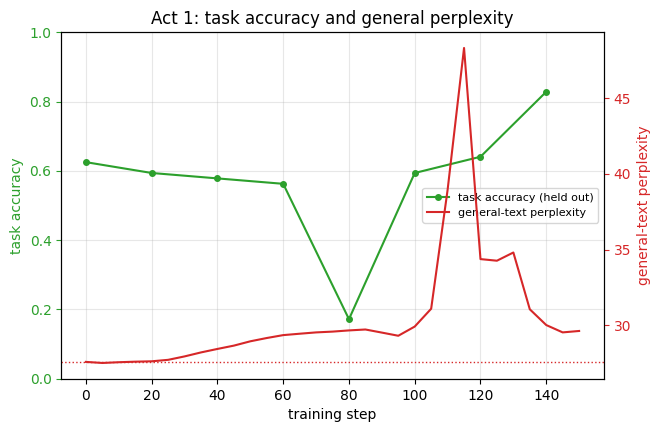

In [16]:
"""The scissors plot. One blade is what we asked for; the other is what we spent."""
dashboard.plot_scissors(
    act1_log,
    title="Act 1: task accuracy and general perplexity",
    baseline_ppl=before["general_perplexity"],
    baseline_accuracy=before["task_accuracy"],
)
plt.show()

### Exercise 2

Write the interpretation. Three questions, in the cell below:

1. What improved?
2. What degraded?
3. **Was anything in the training objective asking for the second thing?** Go and re-read
   `format_reward` and `correctness_reward`. Point at the line that mentions English
   prose.

<!-- TODO(hint): what improved, what degraded, and was anything in the objective asking for the second thing? -->
<!-- BEGIN SOLUTION -->
**1.** The rewarded behaviour improved, and fast. Format compliance is essentially solved
within the first ten to fifteen steps - the model learns to wrap its output in `<think>`
and `<answer>` tags almost immediately, because that is the cheapest reward available, and
total reward reaches its ceiling of 3.0. Held-out accuracy rises above the Act 0 baseline,
from 0.625 to around 0.80.

**2.** Two different answers depending on which outcome you got, and it is worth writing
down both because the *mechanism* is the same.

Under outcome A, everything unrewarded drifted. Completion length collapses - the model
discovers that a short degenerate think block scores exactly as well as a real one, because
nothing pays for the reasoning, only for the tags around it. Policy entropy falls steeply,
which is to say the model stops exploring. General perplexity rises about 8%.

Under outcome B the same drift ran until the policy left the reference distribution
altogether, and then everything went at once: reward to zero, accuracy to zero, entropy to
7.6 nats. Two of the five general prompts stopped producing any output at all.

An honest observation that cuts against the folklore, and worth making explicitly: even in
outcome B the damage was **prompt-conditional**. The model emitted token soup on arithmetic
prompts while still writing perfectly reasonable prose for three of the five general ones.
LoRA at rank 16 constrains the update to a low-dimensional subspace, and that turns out to
be a far stronger protection of unrelated behaviour than "catastrophic forgetting" usually
implies. The general capability degraded by 8-14% on perplexity, not by an order of
magnitude. Do not over-claim from this run - see the last discussion question in Act 5.

**3.** No. That is the entire point. Read the two reward functions again: one counts angle
brackets, the other compares an integer. Neither mentions English prose, general knowledge,
instruction following, or anything else the model could lose. The objective was completely
silent about the general capability, and optimisation pressure is applied to exactly what
is measured and to nothing else. Whatever is not in the objective is not protected by it -
it is not even neutral, because parameters that were doing that job are free to be
repurposed for the one thing that is being scored.

This is the transfer lesson, and it is not a fact about GRPO or about language models. It
is a fact about optimisation: a proxy objective that is silent about a capability will
spend it.

**3.** No. That is the entire point. Read the two reward functions again: one counts angle
brackets, the other compares an integer. Neither mentions English prose, general knowledge,
instruction following, or anything else the model could lose. The objective was completely
silent about the general capability, and optimisation pressure is applied to exactly what
is measured and to nothing else. Whatever is not in the objective is not protected by it -
it is not even neutral, because parameters that were doing that job are free to be
repurposed for the one thing that is being scored.

This is the transfer lesson, and it is not a fact about GRPO or about language models. It
is a fact about optimisation: a proxy objective that is silent about a capability will
spend it.
<!-- END SOLUTION -->

---

# Act 3 - Diagnose

Twelve minutes, no training at all. Everything below is read off the log that Act 1 wrote.

The interesting question is not "did it degrade" - we have established that - but
**which quantity was allowed to grow without limit, and what did that permit?**

In [17]:
"""Every logged quantity, first value against last."""
summary = dashboard.summarise(act1_log)
print(summary.to_string(index=False))

              quantity   first    last  change  ratio  measured_at_steps
                  loss -0.0000  0.0000  0.0000    NaN                150
         learning_rate  0.0001  0.0002  0.0001  3.000                150
           reward_mean  0.7500  3.0000  2.2500  4.000                150
            reward_std  1.2145  0.0000 -1.2145  0.000                150
  frac_zero_std_groups  0.0000  1.0000  1.0000    NaN                150
completion_length_mean 24.1875 17.0000 -7.1875  0.703                150
               entropy  0.5299  0.0046 -0.5253  0.009                150
                    kl  0.0000  0.7000  0.7000    NaN                150
           general_ppl 27.5952 29.6345  2.0393  1.074                 31
         task_accuracy  0.6250  0.8281  0.2031  1.325                  8


Read that table with the six panels above, one at a time:

* **KL to the reference model.** It was never penalised - $\beta = 0$ deleted the term -
  so nothing was pushing back on it. Watch where it ends up.
* **Policy entropy.** Estimated as the mean of $-\log \pi(\text{sampled token})$ over the
  tokens the policy actually sampled. Falling entropy means the policy is becoming
  deterministic - it has stopped exploring, and a policy that has stopped exploring cannot
  discover anything the reward would have paid for.

  A caveat worth knowing, because it is a real trap rather than a technicality: that
  average is an *unbiased* estimate of $H(\pi)$ only if the samples come from $\pi$. In
  TRL 0.15.2 they do not. TRL builds its `GenerationConfig` without setting `top_k`, so it
  inherits the transformers default of 50 and GRPO samples from the top-50 renormalised
  distribution. Measured on this base model that reads about 1.73 nats against a true
  entropy of about 2.24 - roughly 77% of it - because the truncated tail is exactly the
  high-surprisal part. The bias shrinks as the policy sharpens, so the measured *fall* is
  compressed relative to the real one. It is a sound monotone proxy for what we are
  reasoning about here, and it is not a number to quote in a paper. Note also that GRPO's
  importance ratio formally assumes samples drawn from the policy, which top-k truncation
  quietly violates in every TRL GRPO run at this version.
* **Fraction of groups with zero reward standard deviation.** This is the fraction of the
  batch that produced no gradient at all. It interacts with entropy in an unpleasant way:
  as the policy becomes deterministic, the eight sampled completions become *identical*,
  so their rewards are identical, so the advantage is zero, so training stops - while the
  logs continue to look busy.
* **Mean completion length.** Nothing in the reward pays for reasoning, only for the tags
  around it.

In [18]:
"""What the model was actually writing, sampled during training. The drift is legible
here in a way it is not in any curve."""
for step in sorted(act1_completions):
    print(f"--- step {step} " + "-" * 60)
    for text in act1_completions[step]:
        flat = " ".join(text.split())
        print(f"  {flat[:150]}" + (" ..." if len(flat) > 150 else ""))
    print()

--- step 0 ------------------------------------------------------------
  <think>73 times 9 = 657 </think>
  <think>multiply 73 and 9 </think> <answer> 657 </answer>
  <think> 73 times 9 </think> <answer> 657 </answer>

--- step 25 ------------------------------------------------------------
  <think> multiplication </think><answer> 52 </answer>
  <think> multiplication </think><answer> 52 </answer>
  <think> multiplication </think><answer> 52 </answer>

--- step 50 ------------------------------------------------------------
  <think> multiplication </think><answer> 603 </answer>
  <think> multiplication </think><answer> 603 </answer>
  <think> multiplication </think><answer> 603 </answer>

--- step 75 ------------------------------------------------------------
  <think> multiplication </think><answer> 3105> </answer>
  <think> multiplication </think><answer> 3105> </answer>
  <think> multiplication </think><answer> 3105> </answer>

--- step 100 --------------------------------------

### Exercise 3

This is the most important cell in the notebook. Everything else is mechanics.

**Which quantity was unbounded, and why did leaving it unbounded permit what you
observed?**

Answer in terms of the objective, not in terms of "the model got worse".

<!-- TODO(hint): which quantity was unbounded, and why did leaving it unbounded permit what you observed? -->
<!-- BEGIN SOLUTION -->
The unbounded quantity is the **KL divergence between the trained policy and the reference
model**, $\mathbb{D}_{KL}[\pi_\theta \,\|\, \pi_{ref}]$.

Setting $\beta = 0$ deleted that term from the objective. What remained was a pure reward
maximisation over a policy with a very large number of parameters, and the reward was
defined on a narrow slice of input space: prompts that ask for a product, scored by
whether the output has the right tags and the right integer. Nothing in the objective
referred to the model's behaviour anywhere else in input space, so nothing in the
objective *cost* anything for changing that behaviour arbitrarily.

The KL term is not a regulariser in the usual sense - it is not there to prevent
overfitting to the training set. It is a **trust region measured in distribution space**.
It says: you may improve the reward, but you must stay near the model you started from,
and "near" is measured over the whole distribution rather than over the prompts you happen
to be scoring. Without it, the optimiser has a licence to spend any behaviour that is not
being measured, and it will, because those parameters are useful for the thing that *is*
being measured.

Two mechanisms make this concrete in the logs:

1. **The reward is satisfiable by a degenerate policy.** A short, contentless think block
   scores the same as genuine reasoning, so completion length collapses. The model has not
   been rewarded for reasoning at any point; it has been rewarded for the tags.
2. **Entropy collapse makes it self-terminating.** As the policy concentrates, the eight
   sampled completions in a group become identical, their rewards become identical, and
   the advantage becomes exactly zero. Training stops doing anything, but the loss stays
   near zero and the run keeps going. Nothing in a naive training log distinguishes "this
   has converged" from "this has stopped learning and is now merely drifting". Measured
   here: `frac_zero_std_groups` averages about 0.70 across the run.

3. **And there is no restoring force.** This is what makes the cliff possible. A policy
   that wanders into a region where the reward is zero has, under this objective, no reason
   to come back - the advantage is zero there too, because all eight completions are
   equally worthless, so the gradient that would pull it back does not exist. The reference
   run's entropy at step 90 was 7.6 nats against a vocabulary of 152,000 tokens, which is
   very nearly uniform: the model had become a random token generator, and the objective
   was indifferent to that. With $\beta > 0$ the KL term supplies exactly the restoring
   force that is missing, and it is the only thing in the objective that refers to where
   the model *started* rather than to how it is scoring.

The general lesson: when you optimise a proxy, the only thing protecting everything else
is an explicit constraint on how far you are allowed to move. Delete the constraint and
the proxy will be maximised at the expense of whatever was not in it.
<!-- END SOLUTION -->

---

# Act 4 - The fix

Twenty minutes. Same base model, same data, same rewards, same learning rate, same
everything.

**One changed line:** $\beta = 0.04$.

Keeping the learning rate identical to Act 1 is deliberate, and it is worth defending,
because it is tempting to also tune the run to look better. A clean single-variable
ablation is worth more than a better-performing run: if two things changed, the comparison
establishes nothing. Act 4 also gets a *smaller* time budget than Act 1, because the trend
is the point, not convergence.

In [19]:
"""Build the Act 4 configuration, and prove that exactly one thing changed."""
ACT4_CSV = os.path.join(RUNS, "act4.csv")

act4_config = grpo.build_grpo_config(
    beta=0.04,                                    # <-- the leash, on. This is the whole change.
    max_steps=grpo.MAX_STEPS_CAP,
    output_dir=os.path.join(RUNS, "act4_trainer"),
)

difference = grpo.diff_configs(act1_config, act4_config)
print("Differences between the Act 1 and Act 4 configurations:")
for key, (act1_value, act4_value) in difference.items():
    print(f"  {key}: {act1_value}  ->  {act4_value}")
print(f"\n{len(difference)} field(s) differ. If that number is not 1, the comparison below")
print("is not a single-variable ablation and cannot support any conclusion.")

Differences between the Act 1 and Act 4 configurations:
  beta: 0.0  ->  0.04

1 field(s) differ. If that number is not 1, the comparison below
is not a single-variable ablation and cannot support any conclusion.


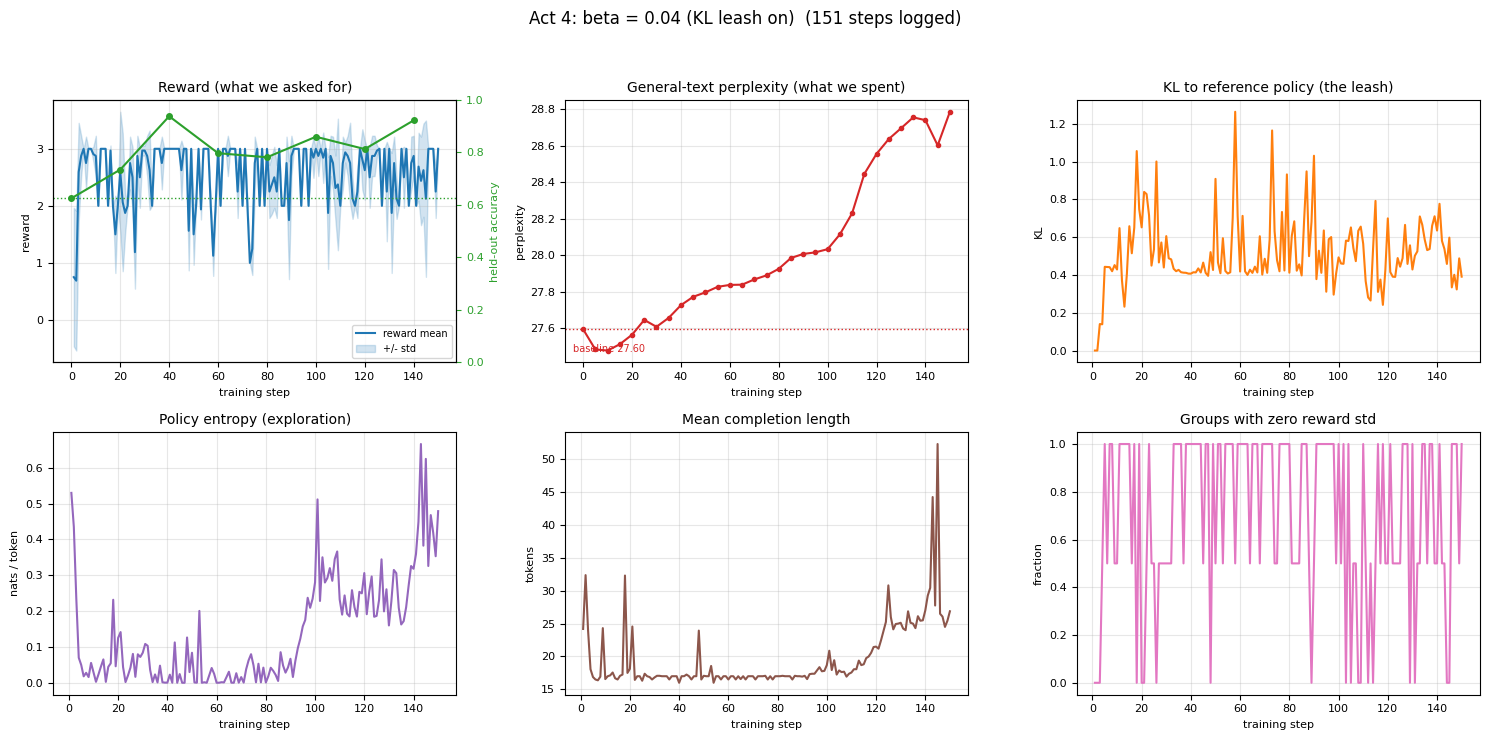

[metrics] 151 rows -> /home/mbunino2/code/26-ADVANCED-ML/rl-practice/notebooks/runs/act4.csv; 705 s total, 69 s of that in evaluation



Act 4 finished: 150 steps in 11.8 min
peak memory: 7.05 GB allocated


In [20]:
"""Act 4. Same code path as Act 1, one different number."""
if TRAIN_FROM_SCRATCH:
    # Start again from the base model, not from the Act 1 adapter: we are comparing two
    # runs from the same starting point, not continuing one.
    del model_act1
    if "act1_trainer" in globals():
        del act1_trainer
    torch.cuda.empty_cache()
    model, tokenizer = grpo.load_model_and_tokenizer(verbose=False)
    torch.cuda.reset_peak_memory_stats()

    act4_budget = TimeBudgetCallback(grpo.ACT4_TIME_BUDGET_SECONDS, grpo.MAX_STEPS_CAP)
    act4_metrics = MetricsCSVCallback(
        csv_path=ACT4_CSV,
        tokenizer=tokenizer,
        eval_dataset=eval_dataset,
        ppl_every=grpo.PPL_EVERY,
        acc_every=grpo.ACC_EVERY,
        acc_n=grpo.ACC_N,
        dashboard_every=10,
        baseline_ppl=before["general_perplexity"],
        baseline_accuracy=before["task_accuracy"],
        title="Act 4: beta = 0.04 (KL leash on)",
    )

    act4_trainer = InstrumentedGRPOTrainer(
        model=model,
        reward_funcs=[format_reward, correctness_reward],
        args=act4_config,
        train_dataset=train_dataset,
        peft_config=grpo.lora_config(),
        callbacks=[NaNGuardCallback(), act4_budget, act4_metrics],
    )

    act4_started = time.time()
    act4_trainer.train()
    act4_wall = time.time() - act4_started

    model_act4 = act4_trainer.model
    act4_log = ACT4_CSV
    print(f"\nAct 4 finished: {act4_trainer.state.global_step} steps in {act4_wall / 60:.1f} min")
    print(f"peak memory: {peak_memory_report()['allocated_gb']:.2f} GB allocated")
else:
    from peft import PeftModel

    act4_log = os.path.join(LOGS, "act4.csv")
    adapter = os.path.join(ASSETS, "reference_adapters", "act4")
    model, tokenizer = grpo.load_model_and_tokenizer(verbose=False)
    model_act4 = PeftModel.from_pretrained(model, adapter)
    print(f"loaded the pre-staged Act 4 adapter from {adapter}")

In [21]:
"""The same frozen evaluation, a third time."""
after_act4 = evaluation.snapshot(
    model_act4, tokenizer, eval_dataset, tag="after_act4", out_dir=SNAPSHOTS, n_task=grpo.N_EVAL
)
evaluation.print_snapshot(after_act4, show_generations=False)

print("\n" + "=" * 78)
print(f"{'':<22}{'base':>10}{'act1 (b=0)':>14}{'act4 (b=0.04)':>16}")
print("=" * 78)
print(f"{'task accuracy':<22}{before['task_accuracy']:>10.3f}"
      f"{after_act1['task_accuracy']:>14.3f}{after_act4['task_accuracy']:>16.3f}")
print(f"{'general perplexity':<22}{before['general_perplexity']:>10.3f}"
      f"{after_act1['general_perplexity']:>14.3f}{after_act4['general_perplexity']:>16.3f}")

=== snapshot: after_act4 ===
  task accuracy (n=64, greedy) : 0.703
  general-text perplexity                      : 28.785

                            base    act1 (b=0)   act4 (b=0.04)
task accuracy              0.625         0.844           0.703
general perplexity        27.595        29.635          28.785


In [22]:
"""The same five general prompts again, base against the KL-constrained run."""
evaluation.compare_snapshots(before, after_act4)

BEFORE (before)  vs  AFTER (after_act4)
  task accuracy : 0.625  ->  0.703   (+0.078)
  general ppl   : 27.595  ->  28.785   (x1.04)

[1/5] Write a short paragraph explaining why sea cliffs retreat over time.
  BEFORE  Sea cliffs, the rugged and often dramatic formations that form on
          the coastlines of many coastal areas around the world,
          undergo significant changes over time due to various
          geological processes. These changes can be attributed to
          several factors:  1. **Natural Weathering**: The
          weathering process involves the gradual erosion of rocks
          and other materials from the surface of the cliff. This
          natural process is driven by factors such as wind, rain,
          and ice, which wear down the rock layers.  2. **
  AFTER   Sea cliffs are formed when the ocean's waves break against the shore
          and erode away at the base of the cliff. Over time, this
          process continues to wear down the cliff, grad

### Exercise 4

Write the comparison plot. You are given both log CSVs; produce the figure that settles
whether the leash worked.

The figure needs to make one claim legible: with $\beta = 0.04$ the blades of the scissors
close - task accuracy still climbs, and general perplexity holds much flatter. Two panels
side by side beats four curves on twin axes, which is unreadable from the back of a
lecture room.

In [23]:
def plot_act_comparison(log_paths, labels, baseline_ppl=None, baseline_accuracy=None):
    """Overlay several runs: accuracy on the left panel, perplexity on the right.

    Arguments:
        log_paths        - list of CSV paths, one per run
        labels           - list of legend labels, same length
        baseline_ppl     - the Act 0 perplexity, drawn as a horizontal reference line
        baseline_accuracy - the Act 0 accuracy, likewise

    Returns the matplotlib Figure.

    Load each CSV with dashboard.load_log(path). Columns are only populated on the steps
    where that quantity was measured, so drop the empty rows before plotting - the
    helper dashboard.series(df, column) returns (steps, values) with NaNs removed.
    """
    # TODO(hint): load each log, plot task_accuracy on the left axis and general_ppl on
    # the right axis, one colour per run, with the baselines as dotted horizontal lines
    # BEGIN SOLUTION
    if len(log_paths) != len(labels):
        raise ValueError(f"{len(log_paths)} logs but {len(labels)} labels")

    fig, (ax_accuracy, ax_perplexity) = plt.subplots(1, 2, figsize=(11, 4.5))

    for i, (path, label) in enumerate(zip(log_paths, labels)):
        frame = dashboard.load_log(path)
        colour = f"C{i}"

        steps, accuracy = dashboard.series(frame, "task_accuracy")
        ax_accuracy.plot(steps, accuracy, color=colour, marker="o", ms=4, label=label)

        steps, perplexity = dashboard.series(frame, "general_ppl")
        ax_perplexity.plot(steps, perplexity, color=colour, label=label)

    if baseline_accuracy is not None:
        ax_accuracy.axhline(baseline_accuracy, color="k", ls=":", lw=1, label="base model")
    if baseline_ppl is not None:
        ax_perplexity.axhline(baseline_ppl, color="k", ls=":", lw=1, label="base model")

    ax_accuracy.set_title("Task accuracy (held out) - higher is better", fontsize=10)
    ax_accuracy.set_ylabel("accuracy")
    ax_accuracy.set_ylim(0, 1)

    ax_perplexity.set_title("General-text perplexity - lower is better", fontsize=10)
    ax_perplexity.set_ylabel("perplexity")

    for axis in (ax_accuracy, ax_perplexity):
        axis.set_xlabel("training step")
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)

    fig.suptitle("Act 1 vs Act 4: does the KL leash close the blades?", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    return fig
    # END SOLUTION

In [24]:
if USE_REFERENCE_SOLUTIONS:
    from rlpractice.dashboard import plot_scissors_comparison as plot_act_comparison  # noqa: F811
    print("using the reference comparison plot (RLPRACTICE_REFERENCE=1)")

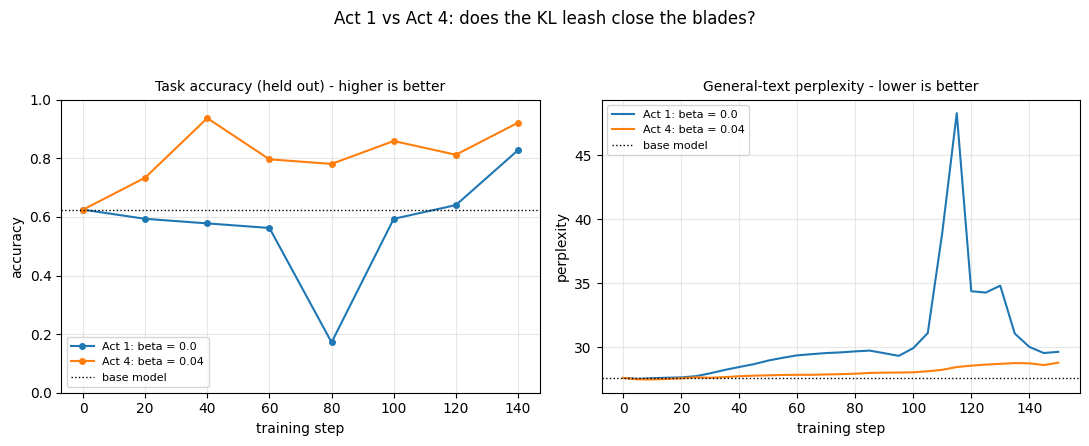

In [25]:
"""The Act 4 payoff figure."""
plot_act_comparison(
    [act1_log, act4_log],
    ["Act 1: beta = 0.0", "Act 4: beta = 0.04"],
    baseline_ppl=before["general_perplexity"],
    baseline_accuracy=before["task_accuracy"],
)
plt.show()

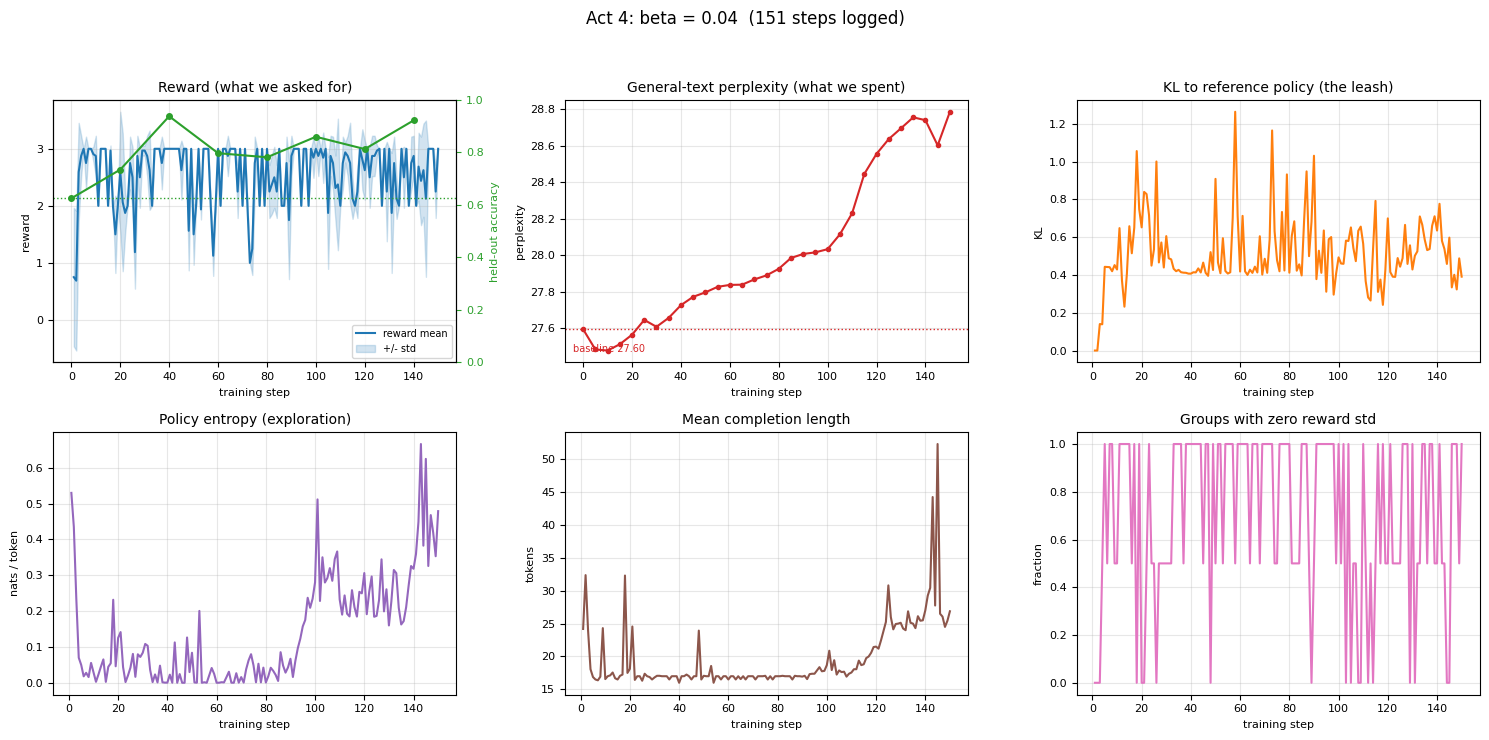

In [26]:
"""And the diagnostic grid for Act 4, for comparison with the Act 1 grid above.
The KL panel is the one to look at: same axes, a leash that is now being pulled."""
dashboard.plot_dashboard(
    act4_log,
    title="Act 4: beta = 0.04",
    baseline_ppl=before["general_perplexity"],
    baseline_accuracy=before["task_accuracy"],
)
plt.show()

---

# Act 5 - Discussion

Nine minutes, no code. Four questions. The first two have good answers; the last two are
about what you should refuse to conclude.

## 1. The KL penalty is one fix. Mixing general data into the RL batch is another, and it is what labs actually do. Why might that work better?

<!-- TODO(hint): why might mixing general data into the RL batch beat a KL penalty? -->
<!-- BEGIN SOLUTION -->
Because a KL penalty is an *undirected* constraint and a data mixture is a *directed* one.

The KL term says "do not move far from the reference model" in every direction at once. It
cannot distinguish movement that costs you general capability from movement that is
exactly the improvement you wanted, so it taxes both. Turn it up enough to protect the
general behaviour and you also throttle the task learning; that trade-off is visible in the
Act 4 curves.

Mixing general data into the batch - a language-modelling loss on ordinary text alongside
the RL objective - instead puts the thing you want to preserve *into the objective*. The
gradient then contains an explicit term for "still be good at prose", so the optimiser is
free to move as far as it likes in directions that do not damage it. You are no longer
paying for protection with a global speed limit.

The cost is that you have to know what to mix in, and you can only protect what you
sampled. A KL leash protects everything a little; a data mixture protects what is in the
mixture a lot and everything else not at all. In practice labs do both.
<!-- END SOLUTION -->

## 2. With LoRA there is a trivial way to avoid forgetting entirely: never merge the adapter. What does that buy, and where does it stop working?

<!-- TODO(hint): what does keeping the adapter unmerged buy, and where does that stop working? -->
<!-- BEGIN SOLUTION -->
It buys perfect, free reversibility. The base weights were never modified - the adapter is
a separate low-rank addition - so you can switch it off and recover the original model
exactly, byte for byte. The "forgetting" we measured is not damage to the base model at
all; it is damage to a *composite* model that we can disassemble at will. Serve the base
model for general chat, switch the adapter in for arithmetic, and you appear to have got
capability for free. This is genuinely how adapter-based deployment works, and it is why
`disable_adapter()` is how TRL computes the reference log-probabilities in the first place.

It stops working the moment you want the two capabilities *at the same time*, in one
forward pass. A user who asks a general question and then a numerical one in the same
conversation cannot be served by two different models mid-turn without you knowing in
advance which is which - and if you could classify the request that reliably, you would
not need the model. It also stops working when you want to stack capabilities: adapters do
not compose cleanly, and training a second adapter on top of a merged first one puts you
straight back where you started. And it does nothing at all for full fine-tuning, which is
what you are doing at frontier scale.

So the honest summary is that not merging converts a capability problem into a routing
problem. That is a real improvement, and it is not a solution.
<!-- END SOLUTION -->

## 3. DeepSeek-R1 used a clip ratio of 10, not the 0.2 typical of classical PPO. What does that tell you about transferring hyperparameters between domains?

<!-- TODO(hint): what does a clip ratio of 10 versus 0.2 tell you about hyperparameter transfer? -->
<!-- BEGIN SOLUTION -->
That the numbers you inherit encode assumptions about the domain they came from, and those
assumptions do not travel.

PPO's clip ratio bounds how far the policy may move in one update, expressed as a
probability ratio. The value 0.2 was tuned for continuous-control tasks with dense rewards,
short horizons, and a policy over a handful of continuous action dimensions - a regime
where a large ratio really does mean an unstable update. A language model's action space
is one token out of 152,000, most of which have tiny probabilities. Ratios that would be
alarming in a robotics policy are routine here, simply because the base probabilities are
so small; clipping at 0.2 would throttle almost every useful update.

The general point is that a hyperparameter is a claim about scale, and scale is set by the
problem. "Clip ratio 0.2" is not a fact about PPO; it is a fact about a benchmark suite
from 2017. When you move to a new domain, the *structure* of an algorithm transfers and its
constants usually do not - and the constants are the part everyone copies, because they
look like part of the method rather than part of the tuning.

The corollary worth carrying away: when an inherited hyperparameter seems to be doing
nothing, or seems to be doing far too much, suspect that it was calibrated against a
different scale before you suspect the algorithm.
<!-- END SOLUTION -->

## 4. R1-Zero needed a 32B+ base model before pure RL produced emergent reasoning. Given that, what should you *not* conclude from the 0.5B run you just did?

<!-- TODO(hint): what should you NOT conclude from a 0.5B run, given that R1-Zero needed 32B+? -->
<!-- BEGIN SOLUTION -->
You should not conclude anything about **whether RL can teach reasoning**, in either
direction.

What you saw is a small model learning an output *format* very fast and its arithmetic
improving modestly. What you did not see is the thing R1-Zero is famous for: long
chains of thought emerging on their own, the model spontaneously backtracking, checking its
work, and allocating more tokens to harder problems. Our model went the other way - its
completions got shorter, and the think block became decorative. It would be easy, and
wrong, to read that as evidence that RL does not produce reasoning.

The reason is that RL with a verifiable reward can only amplify behaviours the base model
already produces with non-negligible probability. It is a search over the policy's existing
support, not a source of new capability. If a 0.5B model essentially never emits a correct
multi-step derivation, then no amount of rewarding correct answers will find one, because
the reward never fires on that behaviour and there is nothing to reinforce. At 32B the
behaviour is already in the sampling distribution occasionally, and RL can find it and make
it reliable. The capability was latent; RL made it consistent.

Two habits follow. First, be careful about scale-dependent claims: a negative result at
0.5B is evidence about 0.5B and very little else, and "we tried it and it did not work" is
not a statement about the method until you say at what scale. Second, when a reward fails
to elicit a behaviour, ask whether the behaviour was ever in the samples - the fraction of
zero-variance groups from Act 3 is exactly this diagnostic, and it is cheap to look at.
<!-- END SOLUTION -->

---

## What to take away

One sentence, and it is not about language models:

**Optimisation pressure is applied to exactly what you measure, and to nothing else. Whatever your objective is silent about, it will spend.**

The KL term in GRPO is one way of saying "and please do not spend everything else". It is
not the only way, it is not free, and noticing that you need *something* in that slot is
the part that transfers.